In [1]:
# Reproducible, Colab-safe setup
import importlib.util, subprocess, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

required = {"mlxtend": "mlxtend", "wordcloud": "wordcloud", "psutil": "psutil"}
missing = [pkg for pkg, module in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
OUTPUT_DIR = Path("Output_Screenshots")
OUTPUT_DIR.mkdir(exist_ok=True)

def save_table_image(frame, filename, title, max_rows=12):
    shown = frame.head(max_rows).copy()
    fig_h = max(2.6, 0.38 * (len(shown) + 2))
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    table = ax.table(cellText=shown.values, colLabels=shown.columns,
                     cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.35)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#1f4e79")
            cell.set_text_props(color="white", weight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

Dataset shape: (683, 4) Missing values: 0


,User,Movie,Genre,Rating
0,User_01,Movie_17,Drama,2.3
1,User_01,Movie_05,Romance,2.5
2,User_01,Movie_21,Action,2.7
3,User_01,Movie_30,Romance,4.0
4,User_01,Movie_28,Comedy,3.9
5,User_01,Movie_01,Action,3.7
6,User_01,Movie_15,Romance,2.5
7,User_01,Movie_16,Action,3.2
8,User_01,Movie_24,Sci-Fi,2.4
9,User_01,Movie_25,Romance,2.0


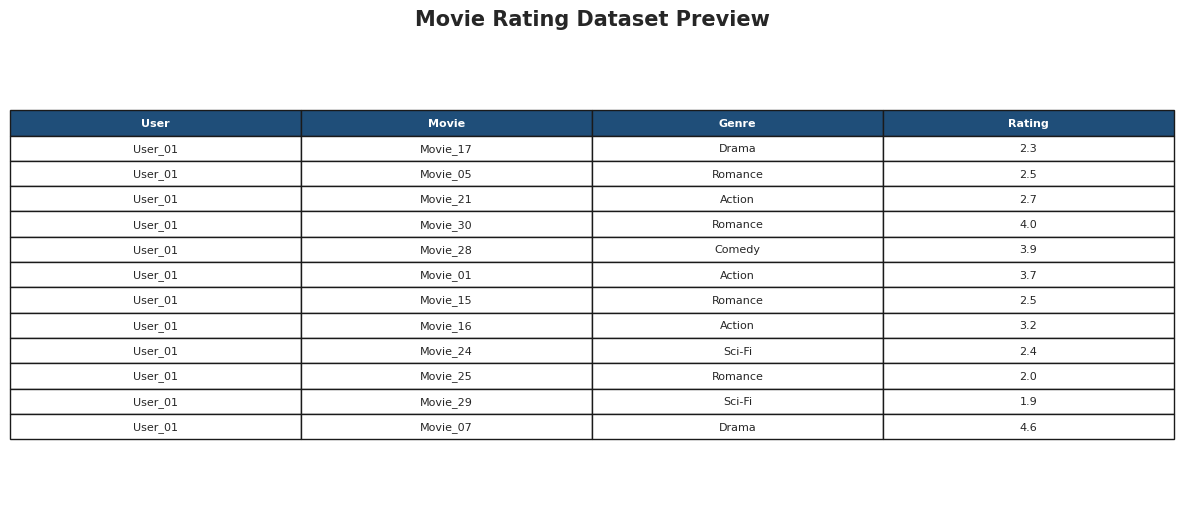

Movie,Movie_01,Movie_02,Movie_03,Movie_04,Movie_05,Movie_06,Movie_07,Movie_08,Movie_09,Movie_10
User,,,,,,,,,,
User_01,3.7,NaN,3.4,NaN,2.5,NaN,4.6,NaN,NaN,NaN
User_02,3.1,3.3,3.0,NaN,3.4,NaN,NaN,NaN,2.4,2.7
User_03,3.0,NaN,2.7,3.6,4.1,3.5,2.6,3.5,NaN,NaN
User_04,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_05,NaN,NaN,3.6,2.0,NaN,1.8,NaN,NaN,3.4,NaN
User_06,NaN,2.8,NaN,NaN,NaN,NaN,NaN,NaN,3.2,2.8
User_07,2.5,NaN,NaN,NaN,2.5,NaN,2.5,NaN,NaN,3.8
User_08,2.3,NaN,2.6,NaN,NaN,NaN,2.3,NaN,NaN,NaN


In [2]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error,mean_absolute_error

users=[f"User_{i:02d}" for i in range(1,51)]
movies=[f"Movie_{i:02d}" for i in range(1,31)]
genres=np.array(["Action","Drama","Comedy","Sci-Fi","Romance"])
user_pref=rng.normal(size=(len(users),5)); movie_attr=rng.normal(size=(len(movies),5))
rows=[]
for u in range(len(users)):
    rated=rng.choice(len(movies),size=rng.integers(10,19),replace=False)
    for m in rated:
        rating=np.clip(3+user_pref[u]@movie_attr[m]/3+rng.normal(0,.45),1,5)
        rows.append((users[u],movies[m],genres[m%len(genres)],round(float(rating),1)))
ratings=pd.DataFrame(rows,columns=["User","Movie","Genre","Rating"])
print("Dataset shape:",ratings.shape,"Missing values:",ratings.isna().sum().sum())
display(ratings.head(10)); save_table_image(ratings.head(12),"01_dataset_preview.png","Movie Rating Dataset Preview")
matrix=ratings.pivot_table(index="User",columns="Movie",values="Rating")
display(matrix.iloc[:8,:10])

In [3]:
# Hold out one observed rating per user for leakage-safe evaluation.
test_idx=ratings.groupby("User",group_keys=False).sample(1,random_state=SEED).index
train=ratings.drop(test_idx); test=ratings.loc[test_idx]
train_matrix=train.pivot_table(index="User",columns="Movie",values="Rating").reindex(index=users,columns=movies)
global_mean=train.Rating.mean(); user_means=train.groupby("User").Rating.mean()
filled=train_matrix.apply(lambda row: row.fillna(row.mean()),axis=1).fillna(global_mean)

# Item-based cosine prediction.
item_sim=pd.DataFrame(cosine_similarity(filled.T),index=movies,columns=movies)
def item_predict(user,movie):
    seen=train[train.User==user]
    if seen.empty:return global_mean
    weights=item_sim.loc[movie,seen.Movie].to_numpy(); vals=seen.Rating.to_numpy()
    return float(np.average(vals,weights=np.abs(weights))) if np.abs(weights).sum() else float(user_means.get(user,global_mean))
item_pred=np.array([item_predict(r.User,r.Movie) for _,r in test.iterrows()])

# Low-rank matrix factorization with TruncatedSVD.
svd=TruncatedSVD(n_components=8,random_state=SEED)
reconstructed=svd.fit_transform(filled)@svd.components_
recon=pd.DataFrame(reconstructed,index=users,columns=movies).clip(1,5)
svd_pred=np.array([recon.loc[r.User,r.Movie] for _,r in test.iterrows()])
evaluation=pd.DataFrame({"Approach":["Item-based cosine","TruncatedSVD"],
                         "RMSE":[mean_squared_error(test.Rating,item_pred)**.5,mean_squared_error(test.Rating,svd_pred)**.5],
                         "MAE":[mean_absolute_error(test.Rating,item_pred),mean_absolute_error(test.Rating,svd_pred)]})
display(evaluation.round(3))

,Approach,RMSE,MAE
0,Item-based cosine,0.827,0.651
1,TruncatedSVD,0.824,0.641


Top-N recommendations for User_01


,index,Predicted_Rating
0,Movie_25,3.403
1,Movie_14,3.322
2,Movie_18,3.292
3,Movie_04,3.265
4,Movie_09,3.238


Movies similar to Movie_01


,index,Similarity
0,Movie_08,0.982
1,Movie_23,0.982
2,Movie_09,0.977
3,Movie_22,0.976
4,Movie_11,0.976


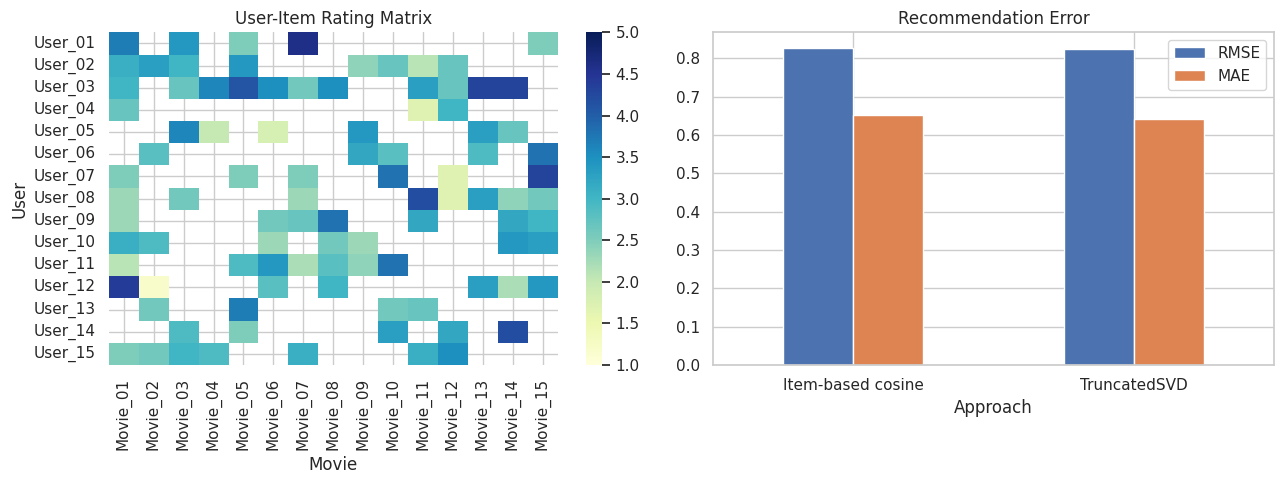

706

In [4]:
selected_user="User_01"
rated=set(train.loc[train.User==selected_user,"Movie"])
topn=(recon.loc[selected_user].drop(labels=list(rated),errors="ignore").sort_values(ascending=False).head(5)
      .rename("Predicted_Rating").reset_index())
selected_movie="Movie_01"
similar=item_sim[selected_movie].drop(selected_movie).sort_values(ascending=False).head(5).rename("Similarity").reset_index()
print("Top-N recommendations for",selected_user); display(topn.round(3))
print("Movies similar to",selected_movie); display(similar.round(3))
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.heatmap(matrix.iloc[:15,:15],cmap="YlGnBu",vmin=1,vmax=5,ax=axes[0]); axes[0].set_title("User-Item Rating Matrix")
evaluation.plot.bar(x="Approach",y=["RMSE","MAE"],ax=axes[1]); axes[1].set_title("Recommendation Error"); axes[1].tick_params(axis="x",rotation=0)
fig.tight_layout(); fig.savefig(OUTPUT_DIR/"02_results.png",dpi=180,bbox_inches="tight"); plt.show()
best=evaluation.sort_values("RMSE").iloc[0].Approach
metrics={"rows":len(ratings),"users":len(users),"movies":len(movies),"evaluation":evaluation.round(4).to_dict("records"),
         "best_model":best,"selected_user":selected_user,"top_recommendations":topn.round(3).to_dict("records")}
Path("results.json").write_text(json.dumps(metrics,indent=2))